<a href="https://colab.research.google.com/github/PabloCastroMontes/MC_PC25-26/blob/main/MC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio: simular y visualizar MCs

El objetivo es aprender a simular trayectorias de una MC, usando algunas de las herramientas más habituales de _machine learning_ (las que hemos visto: Python, Numpy, matplotlib). Como resultado final, generaremos algunas de las imágenes vistas en las diapositivas, y haremos simulaciones relacionadas con los dos teoremas de convergencia que hemos visto: el teorema de convergencia de MCs y el teorema ergódico.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

## 1. Simular la trayectoria de una MC

Vamos a definir una función que nos permita generar trayectorias de una MC dada. Primero la definiremos de la manera más sencilla, usando dos bucles ```for```. Después veremos que se puede eliminar uno de los bucles para hacerlo más eficiente.

**Importante**: para una MC con $m$ estados, nosotros nos hemos referido a ellos como $\{1,2,\dots,m\}$. Y queremos que esta función que simula trayectorias nos devuelva efectivamente esos posibles estados.


In [2]:
def simular_trayectorias(P, pi_sup_1, n_samples, n_steps):
  """
  Función para simular trayectorias de una MC.

  Input:
  P: matriz de transición de la MC. Numpy array con shape (m, m), donde m es el número de estados.
  pi_sup_1: distribución inicial de la MC. Numpy array con shape (m,).
  n_samples: número de trayectorias a simular. Int.
  n_steps: número de pasos de la simulación. Int.

  Output:
  trayectorias: trayectorias simuladas. Numpy array con shape (n_samples, n_steps).
  """

  m = len(pi_sup_1)

  trayectorias = np.zeros((n_samples, n_steps), dtype=int)

  trayectorias[:,0] = np.random.choice(range(m), n_samples, p=pi_sup_1)

  for step in range(1, n_steps):
    for sample in range(n_samples):
      estado_actual = trayectorias[sample, step-1]
      trayectorias[sample, step] = np.random.choice(range(m), p=P[estado_actual,:])

  return trayectorias+1

A continuación vamos a hacer una versión más eficiente de esta función, eliminando uno de los bucles ```for``` (concretamente, el que recorre ```n_samples```). El otro bucle, el que recorre ```n_steps```, no se puede eliminar porque la construcción de la cadena es un proceso inherentemente iterativo. Pero la dimensión sobre ```n_samples``` sí que es conceptualmente paralelizable.

In [3]:
def simular_trayectorias_effic(P, pi_sup_1, n_samples, n_steps):
  """
  Función para simular trayectorias de una MC.

  Input:
  P: matriz de transición de la MC. Numpy array con shape (m, m), donde m es el número de estados.
  pi_sup_1: distribución inicial de la MC. Numpy array con shape (m,).
  n_samples: número de trayectorias a simular. Int.
  n_steps: número de pasos de la simulación. Int.

  Output:
  trayectorias: trayectorias simuladas. Numpy array con shape (n_samples, n_steps).
  """

  m = len(pi_sup_1)

  trayectorias = np.zeros((n_samples, n_steps), dtype=int)

  trayectorias[:,0] = np.random.choice(range(m), n_samples, p=pi_sup_1)

  # Geeneramos conjuntamente todas las trayectorias. Para ello, seguimos estos pasos:
  # 1. Convertimos las filas de probabilidad en una función de distribución mediante np.cumsum. Esto define intervalos en el rango [0,1].
  # 2. Generamos un número aleatorio u ~ U(0,1) para cada trayectoria con np.random.rand.
  # 3. Usamos np.argmax(u < P_cumsum) para encontrar el primer índice donde u es menor que la probabilidad acumulada. Este índice representa el estado siguiente.

  P_cumsum = np.cumsum(P, axis=1)
  for step in range(1, n_steps):
    estados_actuales = trayectorias[:, step - 1]
    u = np.random.rand(n_samples, 1) # Genero los n_samples valores aleatorios entre 0 y 1
    trayectorias[:, step] = np.argmax(u < P_cumsum[estados_actuales,:], axis=1)

  return trayectorias + 1

Una vez implementadas ambas opciones, utiliza las siguientes celdas para evaluar su eficiencia.

El comando ```%%timeit``` al principio de una celda hace que se ejecute varias veces y se devuelva un resumen de tiempo de ejecución (media y desviación típica sobre diferentes pruebas).

En mi ejecución, la versión eficiente ha resultado ser más de 250 veces más rápida.

In [4]:
%%timeit
# Celda para la versión menos eficiente
P = np.array([
    [0.2, 0.3, 0.0, 0.0, 0.5],
    [0.0, 0.1, 0.9, 0.0, 0.0],
    [0.0, 0.0, 0.2, 0.8, 0.0],
    [0.0, 0.7, 0.3, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])
pi_sup_1 = np.array([0.2, 0.2, 0.2, 0.2, 0.2])
n_samples = 1000
n_steps = 50
trayectorias = simular_trayectorias(P, pi_sup_1, n_samples, n_steps)

The slowest run took 4.13 times longer than the fastest. This could mean that an intermediate result is being cached.
2.03 s ± 1.02 s per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [5]:
%%timeit
# Celda para la versión más eficiente
P = np.array([
    [0.2, 0.3, 0.0, 0.0, 0.5],
    [0.0, 0.1, 0.9, 0.0, 0.0],
    [0.0, 0.0, 0.2, 0.8, 0.0],
    [0.0, 0.7, 0.3, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])
pi_sup_1 = np.array([0.2, 0.2, 0.2, 0.2, 0.2])
n_samples = 1000
n_steps = 50
trayectorias = simular_trayectorias_effic(P, pi_sup_1, n_samples, n_steps)

2.74 ms ± 111 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


Por último en esta sección, utiliza alguna de las funciones anteriores para generar seis trayectorias durante 50 pasos, y haz una visualización similar a la diapositiva 24.

Puedes utilizar la función ```plt.step```.

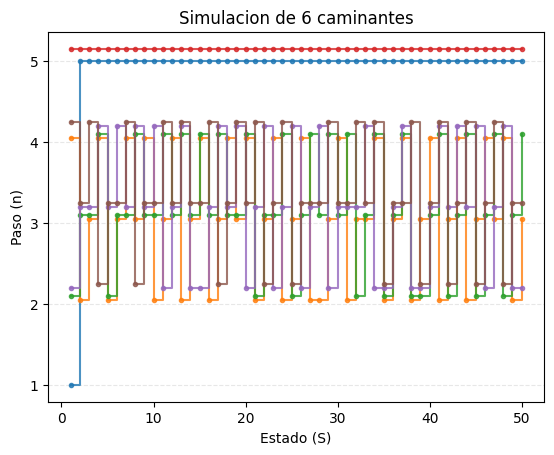

In [6]:
P = np.array([
    [0.2, 0.3, 0.0, 0.0, 0.5],
    [0.0, 0.1, 0.9, 0.0, 0.0],
    [0.0, 0.0, 0.2, 0.8, 0.0],
    [0.0, 0.7, 0.3, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])
pi_sup_1 = np.array([0.2, 0.2, 0.2, 0.2, 0.2])
n_samples = 6
n_steps = 50
trayectorias = simular_trayectorias_effic(P, pi_sup_1, n_samples, n_steps)

# Vamos a desplazar un poco cada trayectoria para que no se superpongan
epsilon = 0.05
desplazamientos = np.arange(n_samples).reshape(-1, 1) * epsilon # columna [0*epsilon, 1*epsilon, 2*epsilon, ..., (n_samples-1)*epsilon]

plt.step(range(1, n_steps + 1), (trayectorias + desplazamientos).T, where='post', marker='o', markersize=3, alpha=0.8) # para la suma de trayectorias+desplazamientos usamos el broadcasting de numpy
plt.xlabel('Estado (S)')
plt.ylabel('Paso (n)')
plt.yticks(range(1, len(pi_sup_1) + 1)) # para que en el eje "y" solo salgan los estados (1,2,...,m)
plt.grid(True, axis='y', alpha=0.3, linestyle='--') # para pintar la malla del fondo
plt.title(f"Simulacion de {n_samples} caminantes") # usamos f-string para poner el "titulo" de la gráfica
plt.show()

## 2. Distribución marginal de una MC

Vamos a definir una función que nos permita obtener la distribución marginal de una MC en un instante dado.

In [7]:
def obtener_marginal(P, pi_sup_1, n):
  """
  Función para calcular la distribución marginal de una MC en cierto instante.

  Input:
  P: matriz de transición de la MC. Numpy array con shape (m, m), donde m es el número de estados.
  pi_sup_1: distribución inicial de la MC. Numpy array con shape (m,).
  n: instante de tiempo en el que se quiere calcular la distribución marginal. Int.

  Output:
  marginal: distribución marginal en el instante n (es decir, lo que hemos llamado pi^{(n)}). Numpy array con shape (m,).
  """
  marginal = pi_sup_1 @ np.linalg.matrix_power(P, n)

  return marginal

Utiliza la función anterior para visualizar empíricamente que la distribución marginal de nuestra MC converge a diferentes distribuciones si empezamos en distribuciones iniciales diferentes. Es decir, reproduce las imágenes de las diapositivas 61 y 63.

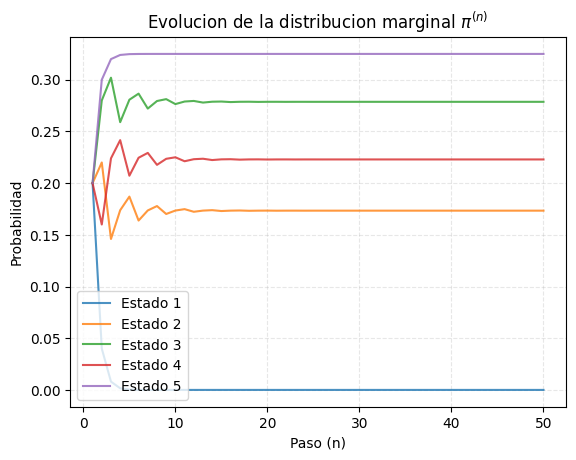

In [8]:
P = np.array([
    [0.2, 0.3, 0.0, 0.0, 0.5],
    [0.0, 0.1, 0.9, 0.0, 0.0],
    [0.0, 0.0, 0.2, 0.8, 0.0],
    [0.0, 0.7, 0.3, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])
pi_sup_1 = np.array([0.2, 0.2, 0.2, 0.2, 0.2])
n = 50

evolucion_pi = np.zeros((len(pi_sup_1),n))
for t in range(n):
    evolucion_pi[:,t] = obtener_marginal(P, pi_sup_1, t)

plt.plot(np.arange(1, n+1), evolucion_pi.T, alpha=0.8)
plt.ylabel('Probabilidad')
plt.xlabel('Paso (n)')
plt.grid(True, alpha=0.3, linestyle='--')
plt.title(r"Evolucion de la distribucion marginal $\pi^{{(n)}}$")
plt.legend([f"Estado {i+1}" for i in range(len(pi_sup_1))], loc='best')
plt.show()

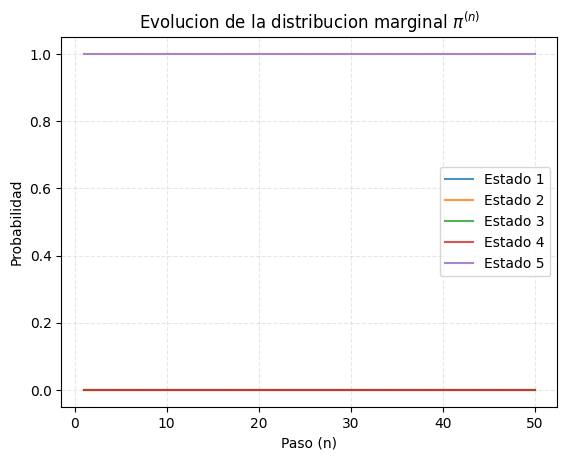

In [9]:
P = np.array([
    [0.2, 0.3, 0.0, 0.0, 0.5],
    [0.0, 0.1, 0.9, 0.0, 0.0],
    [0.0, 0.0, 0.2, 0.8, 0.0],
    [0.0, 0.7, 0.3, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])
pi_sup_1 = np.array([0, 0, 0, 0, 1])
n = 50

evolucion_pi = np.zeros((len(pi_sup_1),n))
for t in range(n):
    evolucion_pi[:,t] = obtener_marginal(P, pi_sup_1, t)

plt.plot(np.arange(1, n+1), evolucion_pi.T, alpha=0.8)
plt.ylabel('Probabilidad')
plt.xlabel('Paso (n)')
plt.grid(True, alpha=0.3, linestyle='--')
plt.title(r"Evolucion de la distribucion marginal $\pi^{{(n)}}$")
plt.legend([f"Estado {i+1}" for i in range(len(pi_sup_1))], loc='best')
plt.show()


## 3. Diagrama de transición de estados

Vamos a definir una función para dibujar el diagrama de transición de estados de una MC. Como hemos visto, esta es una de las formas más habituales de visualizar una MC.

Trata de entender la siguiente función (al menos sus argumentos de entrada y su funcionamiento general, hay detalles sobre los "edge_labels" que son menos relevantes para nosotros).

In [10]:
import networkx as nx

def dibujar_diagrama_transicion(P, states):

  # Use DiGraph (Directed Graph)
  G = nx.DiGraph()
  for i in range(len(P)):
      for j in range(len(P)):
          if P[i, j] > 0:
              G.add_edge(states[i], states[j], weight=P[i, j])

  # Define layout
  pos = nx.circular_layout(G)

  # Create the plot
  plt.figure(figsize=(8, 6))

  # Draw nodes and edges
  # 'connectionstyle' curves the edges to prevent overlap on bidirectional paths
  nx.draw(G, pos, with_labels=True, node_color='lightblue',
          node_size=800, arrowsize=20,
          connectionstyle='arc3, rad = 0.1')

  # 2. Add the weights as labels
  edge_labels = nx.get_edge_attributes(G, 'weight')

  # Optional: Format labels to look cleaner (e.g., 0.5 instead of 0.500000)
  formatted_edge_labels = {k: f"{v:g}" for k, v in edge_labels.items()}

  nx.draw_networkx_edge_labels(G, pos, edge_labels=formatted_edge_labels, label_pos=0.2)

  plt.title("State Transition Diagram with Weights")
  plt.show()

Usa la función anterior para dibujar el diagrama de transición de estados de nuestra MC. Esta es una figura que hemos visto repetidamente (la primera vez en la diapositiva 27).

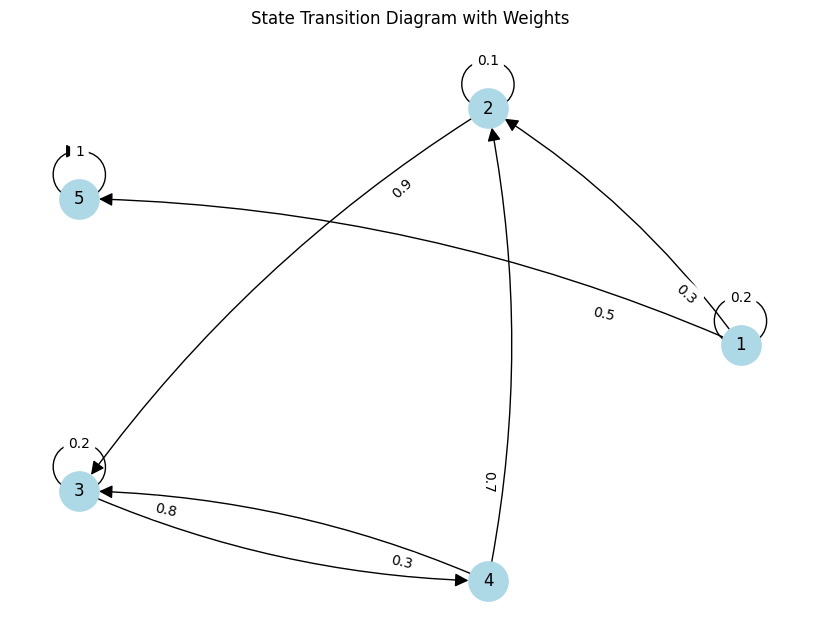

In [11]:
P = np.array([
    [0.2, 0.3, 0.0, 0.0, 0.5],
    [0.0, 0.1, 0.9, 0.0, 0.0],
    [0.0, 0.0, 0.2, 0.8, 0.0],
    [0.0, 0.7, 0.3, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])
states = range(1,6)
dibujar_diagrama_transicion(P, states)

## 4. Teorema de convergencia de MCs

En esta sección vamos a ilustrar tres ideas que hemos estudiado en el contexto del teorema de convergencia de MCs:

1. Una MC es unicadenal y aperiódica $\iff$ la distribución marginal converge siempre a la misma distribución (independientemente de la distribución inicial).
2. Una MC es aperiódica $\iff$ la distribución marginal converge siempre (aunque el límite puede depender de la distribución inicial).
3. Para MCs en las hipótesis del teorema de convergencia de MCs, la distribución empírica de proporciones del estado $i$-ésimo, lo que habíamos llamado $p_i(n_{samples}, n_{steps})$, converge a la componente $i$-ésima de la distribución estacionaria cuando incrementamos $n_{samples}, n_{steps}$.


Vamos a empezar por definir una función que nos permita visualizar la evolución de la distribución marginal de una MC. Este tipo de gráfica ya la habíamos obtenido en la sección 3, cuando se reprodujeron las diapositivas 61 y 63. No obstante, aquí se encapsula en una función y se hace de manera más eficiente que allí:

In [12]:
def visualizar_evolucion_marginal(P, pi_sup_1, n_steps):
  """
  Función para visualizar la evolución de la distribución marginal para una MC.

  Input:
  P: matriz de transición de la MC. Numpy array con shape (m, m), donde m es el número de estados.
  pi_sup_1: distribución inicial de la MC. Numpy array con shape (m,).
  n_steps: instante de tiempo hasta el que se quiere visualizar. Int.

  Output:
  La función no devuelve nada por "return", simplemente realiza un gráfico.
  """
  m = len(pi_sup_1)
  evolucion_marginal = np.zeros((m, n_steps))
  pi_actual = pi_sup_1

  for t in range(n_steps):
    evolucion_marginal[:,t] = pi_actual
    pi_actual = pi_actual @ P

  plt.plot(np.arange(1, n_steps+1), evolucion_marginal.T, alpha=0.8)
  plt.ylabel('Probabilidad')
  plt.xlabel('Paso (n)')
  plt.grid(True, alpha=0.3, linestyle='--')
  plt.title(r"Evolucion de la distribucion marginal $\pi^{(n)}$")
  plt.legend([f"Estado {i+1}" for i in range(m)], loc='best')
  plt.show()

  return

Considera la siguiente matriz de transición:

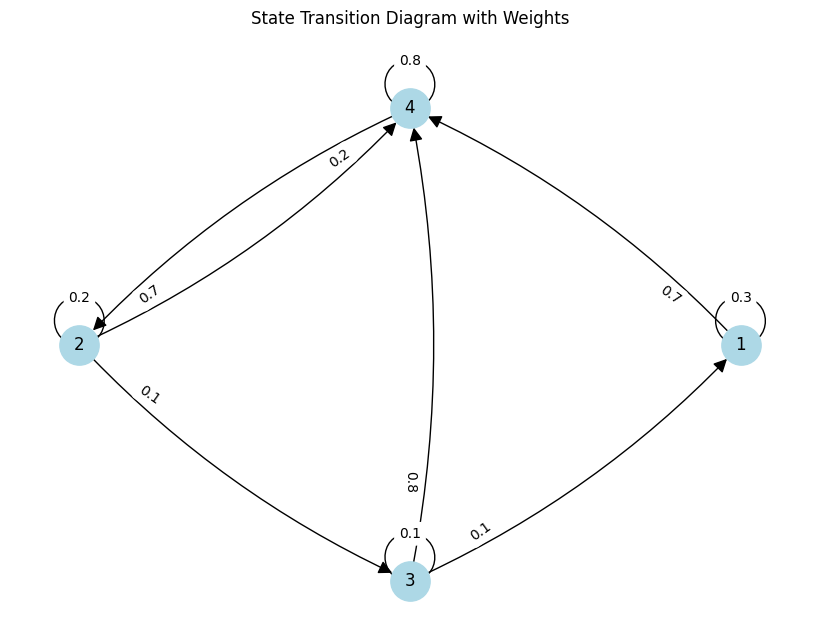

In [13]:
P = np.array([[0.3,0,0,0.7],
              [0,0.2,0.1,0.7],
              [0.1,0,0.1,0.8],
              [0,0.2,0,0.8]])
dibujar_diagrama_transicion(P, [1,2,3,4])

Comprueba que una MC con esta matriz de transición es unicadenal (de hecho es irreducible) y aperiódica. Por tanto, está en las condiciones del teorema de convergencia de MCs. Por tanto, la marginal debe converger a una única distribución estacionaria independientemente de la distribución inicial.

En la siguiente celda se obtiene una distribución inicial aleatoria para la MC, y se representan los primeros $50$ pasos de la marginal (también se imprime por pantalla la marginal en el paso 50). Completa la celda y luego ejecútala varias veces para comprobar que siempre se converge al mismo límite.

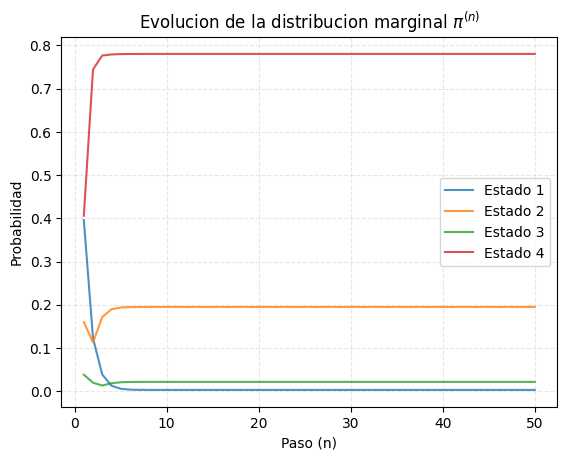

[0.00309598 0.19504644 0.02167183 0.78018576]


In [14]:
P = np.array([[0.3,0,0,0.7],
              [0,0.2,0.1,0.7],
              [0.1,0,0.1,0.8],
              [0,0.2,0,0.8]])

u = np.random.rand(np.shape(P)[1])
pi_sup_1 = u / np.sum(u)

visualizar_evolucion_marginal(P, pi_sup_1, 50)
print( obtener_marginal(P, pi_sup_1, 50) )

Cuando hicimos un esbozo de demostración del teorema de convergencia de MCs, recordar diapositivas 89 y 90, vimos que la sucesión de matrices $\{P^n\}_n$ convergía a una matriz en la que todas las filas eran iguales (y coincidían con la única distribución estacionaria).

Vamos a visualizar varios términos de esta sucesión para comprobar empíricamente que esto sucede. Primero vamos a ver cómo podemos representar visualmente una matriz. Una manera habitual es mediante un "heatmap" (mapa de calor). A continuación se realiza dicho gráfico para la MC anterior (mira el gráfico y entiéndelo en particular el código de color):

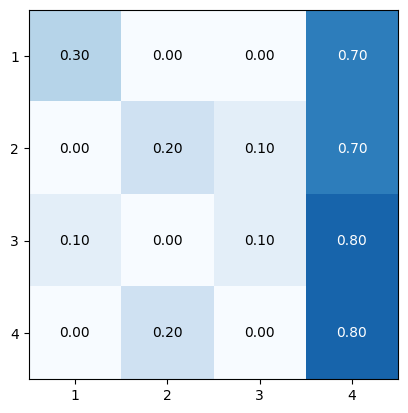

In [15]:
P = np.array([[0.3,0,0,0.7],
              [0,0.2,0.1,0.7],
              [0.1,0,0.1,0.8],
              [0,0.2,0,0.8]])

# Dibujar el heatmap
plt.imshow(P, cmap='Blues', vmin=0, vmax=1)

# Añadir texto con los valores explícitos
m = P.shape[0]
for i in range(m):       # rows
        for j in range(m):   # columns
            value = P[i, j]
            # Dynamically change text color based on cell brightness for readability
            text_color = "white" if value > 0.5 else "black"
            # Add text (note: text coordinates are (column, row) -> (j, i))
            plt.text(j, i, f"{value:.2f}",
                    ha="center", va="center",
                    color=text_color, fontsize=10)

plt.xticks(np.arange(P.shape[0]), labels=1+np.arange(P.shape[0]))
plt.yticks(np.arange(P.shape[0]), labels=1+np.arange(P.shape[0]))

plt.show()

Completa la siguiente celda para ver la evolución de $\{P^n\}_n$ en tres instantes: $n=1,2,10$. Comprueba que, efectivamente, esta sucesión parece estabilizarse en una matriz en las que todas las filas son la misma. Y que además coincide con la distribución estacionaria que obtuvimos empíricamente dos celdas más arriba, cuando vimos dónde parecía estabilizarse la marginal de la MC en el paso $50$. (Recuerda que parecía estabilizarse en [0.00309598 0.19504644 0.02167183 0.78018576]).

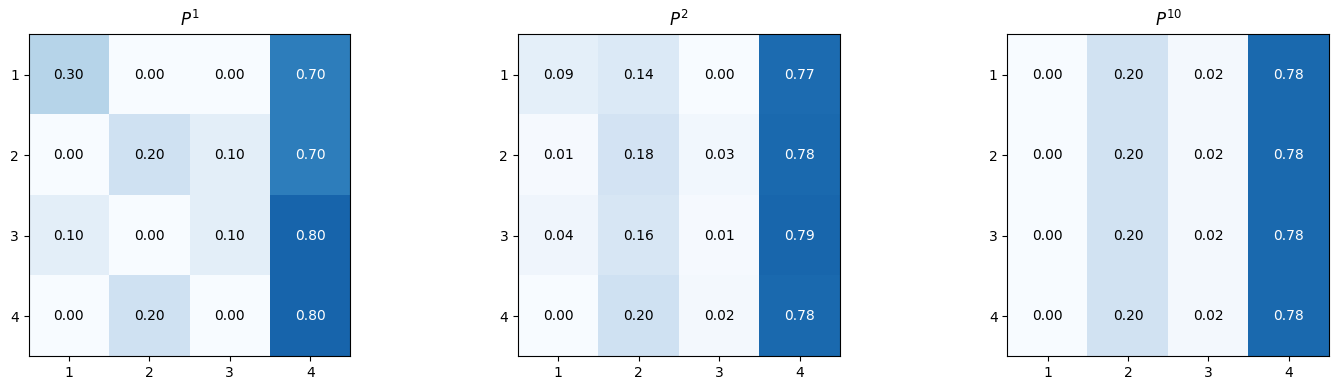

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
steps_to_show = [1, 2, 10]

for ax, n in zip(axes, steps_to_show):

    Pn = np.linalg.matrix_power(P, n)

    im = ax.imshow(Pn, cmap='Blues', vmin=0, vmax=1)
    ax.set_title(f"$P^{{{n}}}$")
    ax.set_xticks(np.arange(P.shape[0]), labels=1+np.arange(P.shape[0]))
    ax.set_yticks(np.arange(P.shape[0]), labels=1+np.arange(P.shape[0]))
    # Loop over data dimensions and create text annotations
    for i in range(Pn.shape[0]):       # rows
        for j in range(Pn.shape[1]):   # columns
            value = Pn[i, j]

            # Dynamically change text color based on cell brightness for readability
            text_color = "white" if value > 0.5 else "black"

            # Add text (note: text coordinates are (column, row) -> (j, i))
            ax.text(j, i, f"{value:.2f}",
                    ha="center", va="center",
                    color=text_color, fontsize=10)

plt.tight_layout()
plt.show()

Vamos ahora a mirar el segundo punto de esta sección. Vamos a mirar una MC que sea periódica. Comprueba que la siguiente MC es periódica (de periodo 2):

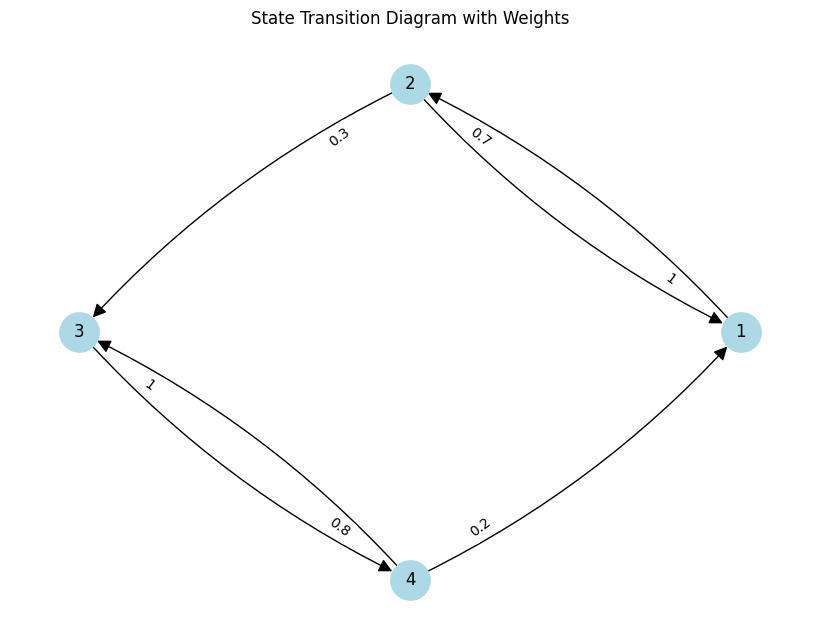

In [17]:
P = np.array([[0.0,1.0,0.0,0.0],
              [0.7,0.0,0.3,0.0],
              [0.0,0.0,0.0,1.0],
              [0.2,0.0,0.8,0.0]])
dibujar_diagrama_transicion(P, np.arange(1,P.shape[0]+1))

En las siguientes tres celdas se usa la función "visualizar_evolucion_marginal" para ver la evolución de la marginal para tres distribuciones iniciales diferentes. En cada celda, también se imprime por pantalla la marginal en el paso $50$:

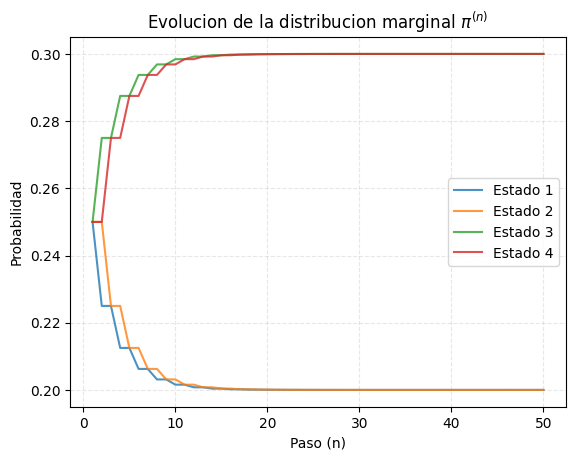

[0.2 0.2 0.3 0.3]


In [18]:
pi_sup_1 = np.array([0.25, 0.25, 0.25, 0.25])
visualizar_evolucion_marginal(P, pi_sup_1, 50)
print(obtener_marginal(P, pi_sup_1, 50) )

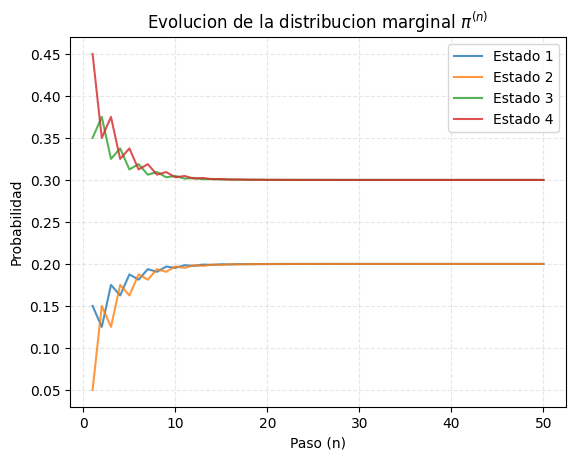

[0.2 0.2 0.3 0.3]


In [19]:
pi_sup_1 = np.array([0.15, 0.05, 0.35, 0.45])
visualizar_evolucion_marginal(P, pi_sup_1, 50)
print(obtener_marginal(P, pi_sup_1, 50) )

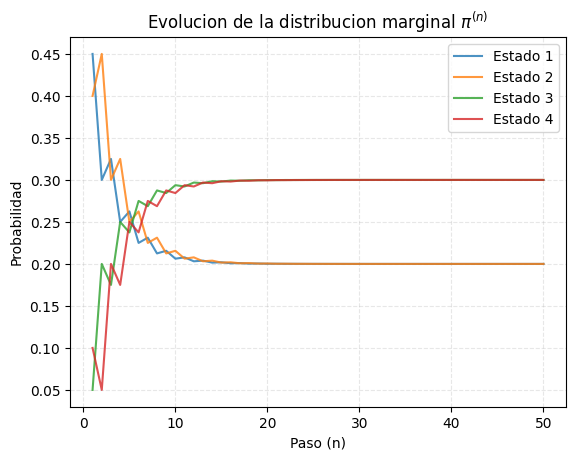

[0.20000001 0.20000001 0.29999999 0.29999999]


In [20]:
pi_sup_1 = np.array([0.45, 0.40, 0.05, 0.10])
visualizar_evolucion_marginal(P, pi_sup_1, 50)
print(obtener_marginal(P, pi_sup_1, 50) )

Observa que, en los tres casos, parece producirse convergencia de la marginal a la distribución [0.2 0.2 0.3 0.3]. Efectivamente, se puede demostrar que la MC converge para esas tres condiciones iniciales. ¿Contradice esto el resultado enunciado en la diapositiva 96?

Para mostrar que no lo contradice, propón en la siguiente celda una distribución inicial para la que no haya convergencia (y visualízalo):

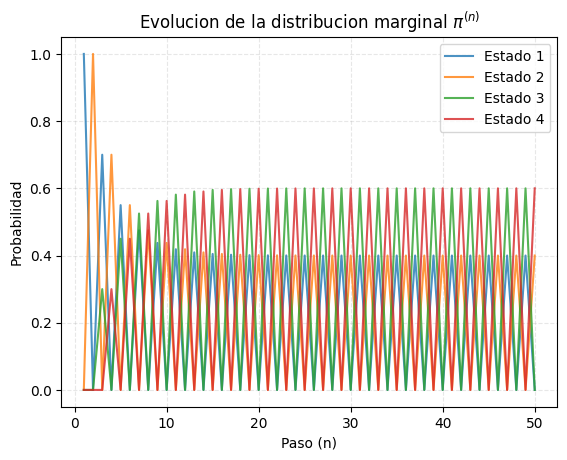

[0.40000002 0.         0.59999998 0.        ]


In [21]:
pi_sup_1 = np.array([1, 0, 0, 0])
visualizar_evolucion_marginal(P, pi_sup_1, 50)
print(obtener_marginal(P, pi_sup_1, 50) )

Vamos a mirar el tercer y último punto de esta sección. En la siguiente celda, vamos a definir una función que calcula las proporciones $p_i(n_{samples}, n_{steps})$ para una trayectoria aleatoria de una MC dada.

De hecho, dada la MC y dados los valores de $n_{samples}$ y $n_{steps}$, la siguiente función devuelve todas las proporciones $p_i(n_{samples}, n)$ con $i=1,\dots,m$ y $n=1,\dots,n_{steps}$.



In [22]:
def proporciones_empiricas_hasta_cierto_paso(n_samples, n_steps, P, pi_sup_1):
  """
  Función que obtiene las proporciones empíricas de cada uno de los estados y en cada uno de los pasos, cuando simulamos una cantidad dada de trayectorias.

  Input:

  n_samples: número de trayectorias a simular. Int.
  n_steps: paso hasta el que se quieren calcular las proporciones. Int.
  P: matriz de transición de la MC. Numpy array con shape (m, m), donde m es el número de estados.
  pi_sup_1: distribución inicial de la MC. Numpy array con shape (m,).

  Output:

  props: Proporciones empíricas, es decir, p_i(n_samples, n) para i=1,...,m y n=1,...,n_steps. Array de shape (m, n_steps).
  """

  m = len(pi_sup_1)

  # Paso 1: utilizar la función "simular_trayectorias_effic" para simular n_samples trayectorias durante n_steps pasos.
  trayectorias = simular_trayectorias_effic(P, pi_sup_1, n_samples, n_steps)  # (n_samples, n_steps)

  # Paso 2: comparar cada item del array anterior con cada uno de los estados i=1,...,m.
  # El objetivo es obtener un array "is_equal_bool" de shape (m, n_samples, n_steps) que en cada posición (i,j,k) contenga True/False según si el ítem (j,k) del array "trayectorias" es igual a "i" (True) o no lo es (False).
  is_equal_bool = np.arange(1, m + 1).reshape(-1, 1, 1) == trayectorias  # (m, n_samples, n_steps)

  # Paso 3: las proporciones a devolver (props) no son más que hacer la media en la dimensión de "n_samples" en el array anterior (cada True cuenta como +1 y cada False cuenta como +0).
  props = np.mean(is_equal_bool, axis=1)   # (m,n_steps)

  return props

Utiliza la función anterior para visualizar la evolución de $p_i(k,k)$ para cada uno de los $i=1,\dots,m$ cuando $k$ crece. Vamos a hacer la visualización para la MC aperiódica y unicadenal que usamos al principio de esta sección. Para ello, rellena la siguiente celda:

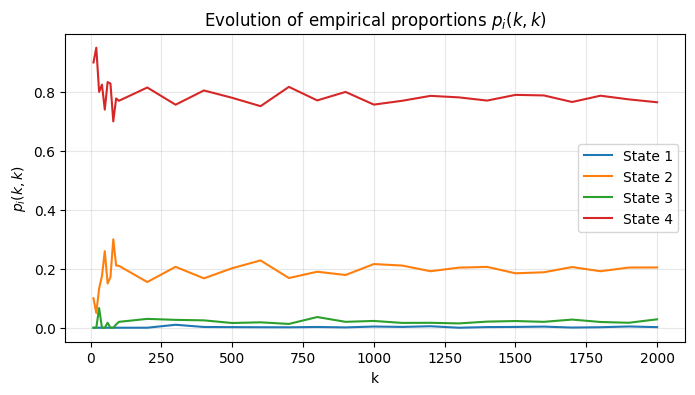

[0.002  0.2045 0.0285 0.765 ]
[0.00309598 0.19504644 0.02167183 0.78018576]


In [23]:
# Definimos la MC
P = np.array([[0.3,0,0,0.7],
              [0,0.2,0.1,0.7],
              [0.1,0,0.1,0.8],
              [0,0.2,0,0.8]])
pi_sup_1 = np.array([0.25, 0.25, 0.25, 0.25])
m = P.shape[0]

# Definimos el "grid" de valores k que vamos a recorrer: 10, 20, 30, ... 100, 200, 300, ..., 2000
grid = np.concatenate( (np.arange(10, 101, 10),
                        np.arange(200, 2001, 100)) )

# Obtenemos p_i(k,k) para i=1,...,m y para k en el grid anterior.
# Guardamos los resultados en un array "props_plot" de shape (m, len(grid)).
props_plot = np.zeros((m, len(grid)))   # (m, len(grid))
for j in range(len(grid)):
  matriz_proporciones = proporciones_empiricas_hasta_cierto_paso(grid[j], grid[j], P, pi_sup_1)
  props_plot[:,j] = matriz_proporciones[:, -1]

# A continuación se hace el gráfico.
plt.figure(figsize=(8, 4))
for i in range(m):
  plt.plot(grid, props_plot[i,:], label=f"State {i+1}")
plt.xlabel("k")
plt.ylabel(r"$p_i(k,k)$")
plt.title(r"Evolution of empirical proportions $p_i(k,k)$")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Mostramos por pantalla dos cosas:
# Primero, las proporciones para el último valor de k, es decir, p_i(2000,2000).
# Segundo, la distribución estacionaria de la MC.
# Lo primero debería parecerse a lo segundo para k grande. Y efectivamente vemos que es así.
print(props_plot[:,-1])
print(obtener_marginal(P, pi_sup_1, 50) )

## 5. Teorema ergódico

En esta sección vamos a verificar empíricamente el teorema ergódico para algunas MCs.

Recuerda que el teorema ergódico se enunciaba para una función $f:S\to\mathbb{R}$ arbitraria. Aquí vamos a considerar la función indicadora $f_i$ que se comentó en la diapositiva 107. Por tanto, estaremos calculando lo que denotábamos por $q_i(n)$ en la diapositiva 106. Recuerda que $q_i(n)$ no es más que la frecuencia (o proporción) de visita al estado $i$-ésimo para una trayectoria aleatoria de la MC, es decir:


$$q_i(n) = \frac{\textrm{Cantidad de veces que se visita $i$ en los $n$ primeros pasos}}{n}$$

Como sabemos, se debe cumplir $q_i(n)\geq 0$ y $\sum_i q_i(n) = 1$.  


Vamos a empezar por definir una función que, dada una MC (```P``` y ```pi_sup_1```) y una cantidad de pasos ```n_steps```, calcule las cantidades $q_i(n)$ para cada $i=1,\dots,m$ y cada $n=1,\dots,n_{steps}$. Estos valores los devolverá en un array con shape (m, n_steps).

In [31]:
def frecuencia_empirica_hasta_cierto_paso(n_steps, P, pi_sup_1):
  """
  Función que calcula la frecuencia empírica de visitas a cada uno de los estados para una trayectoria de una MC hasta cierto paso.

  Input:
  n_steps: paso hasta el que queremos calcular las frecuencias. Se calcularán las frecuencias para n pasos, con n=1,2,..., n_steps. Int.
  P: matriz de transición de la MC. Numpy array con shape (m, m), donde m es el número de estados.
  pi_sup_1: distribución inicial de la MC. Numpy array con shape (m,).

  Output:
  frecuencias_hasta_cierto_paso: frecuencias empíricas obtenidas, es decir el valor q_i(n) para i=1,...,m y n=1,...,n_steps. Array con shape (m, n_steps)
  """

  m = len(pi_sup_1)

  # Paso 1: simular 1 trayectoria para la MC, hasta el paso n_steps
  trayectoria = simular_trayectorias_effic(P, pi_sup_1, 1, n_steps)  # (1, n_steps)

  # Paso 2: compara cada valor obtenido con cada uno de los m posibles estados.
  # El objetivo es obtener un array "is_equal_bool" de shape (m, n_steps) que en la posición (i,j) contenga True/False: True si en el paso j la trayectoria ha visitado justo el estado i, y False en otro caso.
  is_equal_bool = np.arange(1, m+1).reshape(-1, 1) == trayectoria  # (m, n_steps)

  # Paso 3: A partir del array "is_equal_bool" obtenemos un array "recuentos_hasta_cierto_paso" que tenga la misma shape (m, n_steps), y que en el elemento (i,j) contenga
  # la cantidad de veces que se ha visitado el estado i-ésimo hasta el paso j-ésimo.
  recuentos_hasta_cierto_paso = np.cumsum(is_equal_bool, axis=1)  # (m, n_steps)

  # Paso 4: A partir del array "recuentos_hasta_cierto_paso", obtenemos el array "frecuencias_hasta_cierto_paso" que queremos devolver.
  frecuencias_hasta_cierto_paso = recuentos_hasta_cierto_paso / np.arange(1, n_steps+1).reshape(1, -1)  # (m, n_steps)

  return frecuencias_hasta_cierto_paso  # (m, n_steps)


Vamos a usar esta función para visualizar el teorema ergódico en dos MCs que son unicadenales, y por tanto están en las hipótesis del teorema ergódico. Primero miraremos una aperiódica (y que por tanto también está en las condiciones del teorema de convergencia de MCs) y luego miraremos una periódica (y que por tanto NO está en las condiciones del teorema de convergencia de MCs).

Como unicadenal aperiódica tomamos la que hemos usado al principio de la sección 4 anterior:

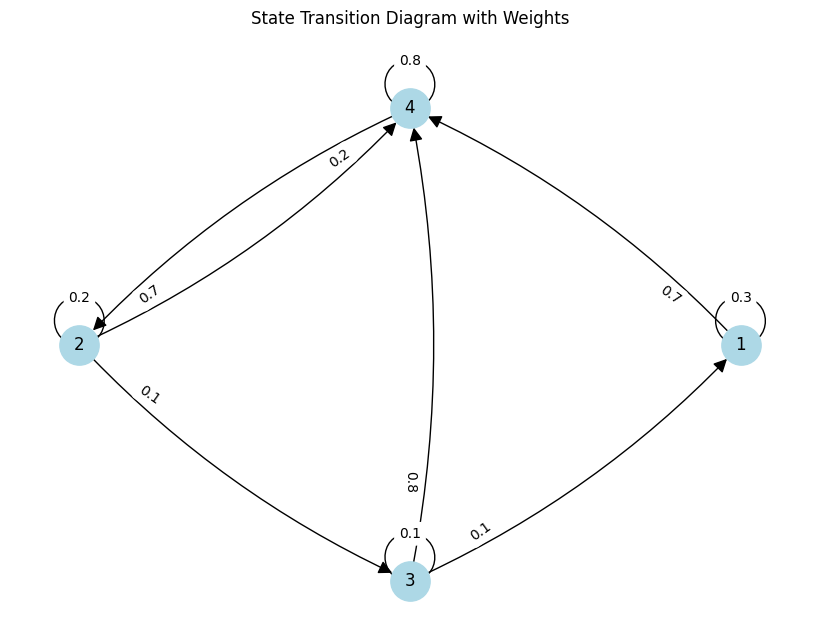

In [25]:
P = np.array([[0.3,0,0,0.7],
              [0,0.2,0.1,0.7],
              [0.1,0,0.1,0.8],
              [0,0.2,0,0.8]])
dibujar_diagrama_transicion(P, [1,2,3,4])

Recordamos de la sección 4 que la distribución estacionaria de esta MC parecía estar entorno a
$$[0.003, \; 0.195, \; 0.022, \; 0.780]$$
puesto que la marginal se estabilizaba en esos valores. Veamos que, tal y como garantiza el teorema ergódico, las cantidades $q_i(n)$ convergen a la distribución estacionaria, es decir, $q_i(n) \to (\pi)_i$ cuando $n\to\infty$.

En la siguiente celda se representa la evolución de cada una de las $q_i(n)$ cuando $n$ crece (desde $1$ hasta $10000$). Al final del todo también se imprimen por pantalla los valores de $q_i(10000)$, para poder compararlos con la distribución estacionaria.

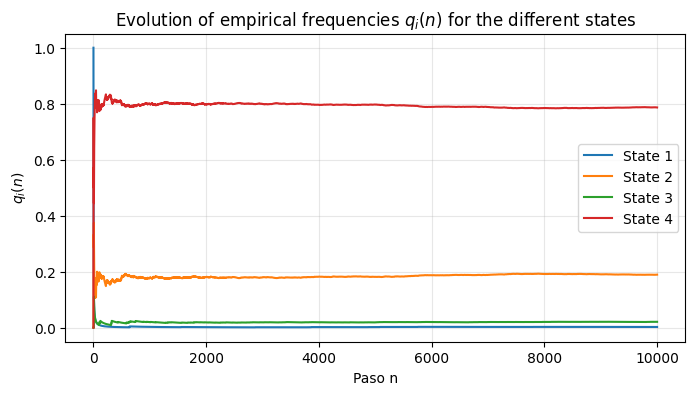

[0.0027 0.1895 0.0211 0.7867]


In [30]:
P = np.array([[0.3,0,0,0.7],
              [0,0.2,0.1,0.7],
              [0.1,0,0.1,0.8],
              [0,0.2,0,0.8]])
pi_sup_1 = np.array([0.25, 0.25, 0.25, 0.25])

n_steps = 10000
m = P.shape[0]

frecs = frecuencia_empirica_hasta_cierto_paso(n_steps, P, pi_sup_1)  # (m, n_steps)

plt.figure(figsize=(8, 4))
for i in range(m):
  plt.plot(np.arange(1, n_steps+1), frecs[i,:] , label=f"State {i+1}")
plt.xlabel("Paso n")
plt.ylabel(r"$q_i(n)$")
plt.title(r"Evolution of empirical frequencies $q_i(n)$ for the different states")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(frecs[:,-1])

Por último, vamos a considerar la MC periódica que vimos en la sección 4:

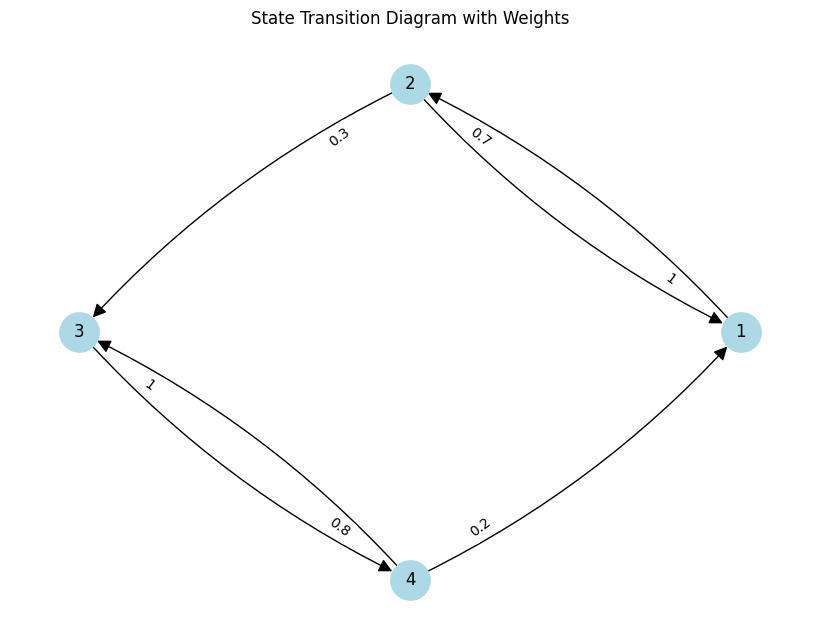

In [32]:
P = np.array([[0.0,1.0,0.0,0.0],
              [0.7,0.0,0.3,0.0],
              [0.0,0.0,0.0,1.0],
              [0.2,0.0,0.8,0.0]])
dibujar_diagrama_transicion(P, np.arange(1,P.shape[0]+1))

Vamos a seleccionar una distribución inicial ```pi_sup_1``` para la que sabemos que la distribución marginal no converge, como se vio en la sección 4. Y vamos a ver que, aunque la distribución marginal no converge, sí que se cumple el teorema ergódico, y las frecuencias a lo largo de una trayectoria sí que convergen a la distribución estacionaria. En efecto, recuerda que el teorema ergódico no requiere "aperiodicidad" (a diferencia del teorema de convergencia de MCs).

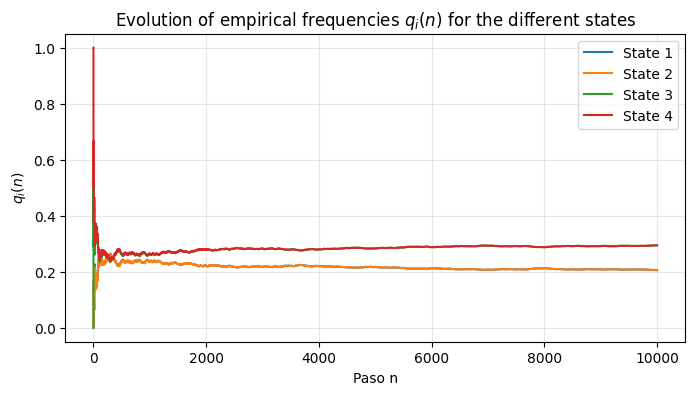

[0.2057 0.2056 0.2943 0.2944]


In [33]:
P = np.array([[0.0,1.0,0.0,0.0],
              [0.7,0.0,0.3,0.0],
              [0.0,0.0,0.0,1.0],
              [0.2,0.0,0.8,0.0]])
pi_sup_1 = np.array([0.2, 0.3, 0.2, 0.3])

n_steps = 10000
m = P.shape[0]

frecs = frecuencia_empirica_hasta_cierto_paso(n_steps, P, pi_sup_1)  # (m, n_steps)

plt.figure(figsize=(8, 4))
for i in range(m):
  plt.plot(np.arange(1, n_steps+1), frecs[i,:] , label=f"State {i+1}")
plt.xlabel("Paso n")
plt.ylabel(r"$q_i(n)$")
plt.title(r"Evolution of empirical frequencies $q_i(n)$ for the different states")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(frecs[:,-1])

Esto converge al valor esperado. En efecto, recuerda de la sección 4 que la única distribución estacionaria de esta MC venía dada por: [0.2, 0.2, 0.3, 0.3].